In [1]:
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

# Evolution Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# STEP 2 — Load Dataset 📂

In [3]:
# Load CSV File
df = pd.read_csv('DECISION TREE_Creditcard.csv')

# Display First 5 Rows
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

# STEP 3 — Dataset Information 🔍

In [4]:
# Dataset shape
print("Dataset Shape :")
print(df.shape)

Dataset Shape :
(35791, 31)


In [5]:
# Column Names
print("Column Names :")
print(df.columns)

Column Names :
Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')


In [6]:
# Dataset Information
print("Dataset Information :")
print(df.info())

Dataset Information :
<class 'pandas.DataFrame'>
RangeIndex: 35791 entries, 0 to 35790
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    35791 non-null  int64  
 1   V1      35791 non-null  float64
 2   V2      35791 non-null  float64
 3   V3      35791 non-null  float64
 4   V4      35791 non-null  float64
 5   V5      35791 non-null  float64
 6   V6      35791 non-null  float64
 7   V7      35791 non-null  float64
 8   V8      35791 non-null  float64
 9   V9      35791 non-null  float64
 10  V10     35791 non-null  float64
 11  V11     35791 non-null  float64
 12  V12     35791 non-null  float64
 13  V13     35791 non-null  float64
 14  V14     35791 non-null  float64
 15  V15     35791 non-null  float64
 16  V16     35791 non-null  float64
 17  V17     35791 non-null  float64
 18  V18     35791 non-null  float64
 19  V19     35791 non-null  float64
 20  V20     35791 non-null  float64
 21  V21     35791 non-null  

In [7]:
# Statistical Summary
print("Statistical Summary :")
print(df.describe())

Statistical Summary :
               Time            V1            V2            V3            V4  \
count  35791.000000  35791.000000  35791.000000  35791.000000  35791.000000   
mean   24016.817468     -0.207898      0.072287      0.718419      0.195676   
std    12426.331378      1.836236      1.539877      1.540295      1.408997   
min        0.000000    -30.552380    -40.978852    -31.103685     -5.172595   
25%    12315.000000     -0.959617     -0.499846      0.244746     -0.714642   
50%    29015.000000     -0.233059      0.113371      0.827531      0.188855   
75%    34275.500000      1.162290      0.754515      1.456338      1.078772   
max    38267.000000      1.960497     16.713389      4.101716     13.143668   

                 V5            V6            V7            V8            V9  \
count  35791.000000  35791.000000  35791.000000  35791.000000  35791.000000   
mean      -0.216779      0.095746     -0.116891      0.032751      0.258905   
std        1.388189      1.31

# STEP 4 — Check Missing Values 🚨

In [8]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64


# STEP 5 — Handle Missing Values 🔥

In [9]:
# Fill Numeric Missing Values
for column in df.columns:
    if df[column].dtype != 'object':
        df[column].fillna(df[column].mean(), inplace = True)
        
# Fill Categorical Missing Values
for column in df.columns:
    if df[column].dtype == 'object':
        df[column].fillna(df[column].mode()[0], inplace = True)
        
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64


# STEP 6 — Check Duplicate Rows 🔁

In [10]:
print("Duplicates Rows :", df.duplicated().sum())

Duplicates Rows : 140


# STEP 7 — Remove Unnecessary Columns ❌

In [11]:
remove_columns = ['ID', 'Id', 'CusomerID', 'customerID', 'TransactionID']

for column in remove_columns:
    if column in df.columns:
        df.drop(column, axis = 1, inplace = True)
        
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

# STEP 8 — Identify Target Column 🎯

In [12]:
# Example Target Column

TARGET = 'Class'

print(df[TARGET].value_counts())

Class
0.0    35687
1.0      103
Name: count, dtype: int64


# STEP 9 — Target Variable Visualization 📊

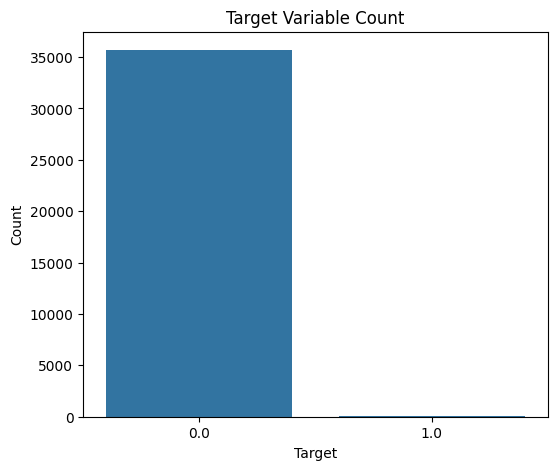

In [13]:
plt.figure(figsize=(6,5))

sns.countplot(x = TARGET, data = df)

plt.title("Target Variable Count")

plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

# STEP 10 — Encode Categorical Columns 🔥

In [14]:
le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])
        
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

# STEP 11 — Correlation Heatmap 🌡️

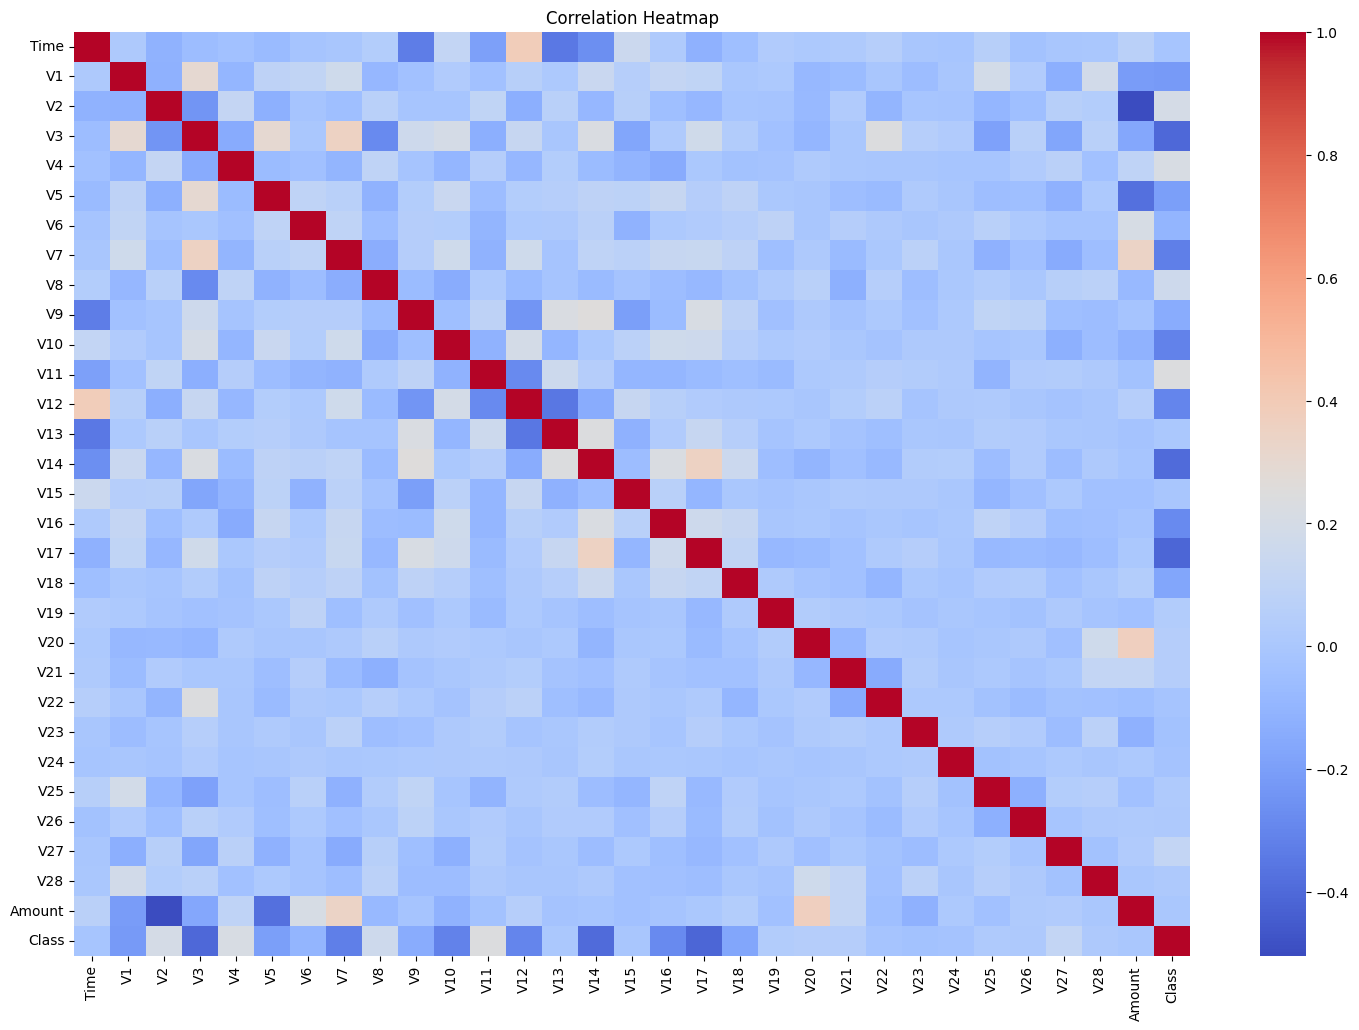

In [15]:
plt.figure(figsize = (18,12))

sns.heatmap(df.corr(), cmap = 'coolwarm')

plt.title('Correlation Heatmap')

plt.show()

# STEP 12 — Define Features and Target 🎯

In [16]:
# DEFINE X AND Y

X = df.drop(TARGET, axis = 1)
y = df[TARGET]

print(X.head())
print(y.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V20       V21       V22       V23       V24  \
0  0.098698  0.363787  ...  0.251412 -0.018307  0.277838 -0.110474  0.066928   
1  0.085102 -0.255425  ... -0.069083 -0.225775 -0.638672  0.101288 -0.339846   
2  0.247676 -1.514654  ...  0.524980  0.247998  0.771679  0.909412 -0.689281   
3  0.377436 -1.387024  ... -0.208038 -0.108300  0.005274 -0.190321 -1.175575   
4 -0.270533  0.817739  ...  0.408542 -0.009431  0.798278 -0.137458  0.141267   

        V25       V26       V27 

# STEP 13 — Train Test Split ✂️

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

print("X_train shape :", X_train.shape)
print("X_test shape :", X_test.shape)

X_train shape : (28632, 30)
X_test shape : (7159, 30)


# STEP 14 — Build Decision Tree Model 🌳

In [18]:
# #model = DecisionTreeClassifier(
#     #criterion='gini',
#     #max_depth=5,
#     #min_samples_split=10,
#     #min_samples_leaf=5,
#     #random_state=42
# #)

# # Train Model
# #model.fit(X_train, y_train)



# from sklearn.tree import DecisionTreeRegressor

# model = DecisionTreeRegressor(
#     criterion='squared_error',
#     max_depth=5,
#     min_samples_split=10,
#     min_samples_leaf=5,
#     random_state=42
# )

# # Train Model
# model.fit(X_train, y_train)

In [19]:
mask = ~np.isnan(y_train)
X_train = X_train[mask]
y_train = y_train[mask]

# Model
model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

# Train
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

📌 Step 15 — Prediction

In [20]:
y_pred = model.predict(X_test)

print(y_pred)

[0. 0. 0. ... 0. 0. 0.]


📌 Step 16 — Accuracy Score

In [21]:
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy Score :", accuracy)

Accuracy Score : 0.9981841039251292


📌 Step 17 — Confusion Matrix

In [24]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[7125    4]
 [   9   21]]


📌 Step 18 — Confusion Matrix Graph

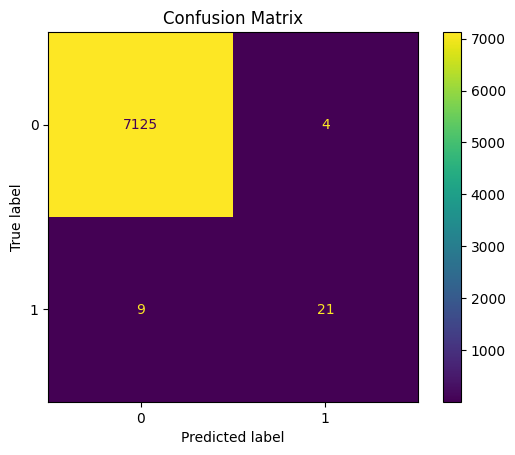

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay


ConfusionMatrixDisplay(confusion_matrix=cm).plot()

plt.title('Confusion Matrix')

plt.show()

📌 Step 19 — Classification Report

In [26]:
report = classification_report(y_test, y_pred)

print(report)

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      7129
         1.0       0.84      0.70      0.76        30

    accuracy                           1.00      7159
   macro avg       0.92      0.85      0.88      7159
weighted avg       1.00      1.00      1.00      7159



📌 Step 20 — Feature Importance

In [27]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# Sort values
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

   Feature  Importance
12     V12    0.674102
26     V26    0.172730
17     V17    0.063264
0     Time    0.040436
14     V14    0.020290
20     V20    0.015508
13     V13    0.010514
19     V19    0.003155
6       V6    0.000000
4       V4    0.000000


📌 Step 21 — Feature Importance Graph

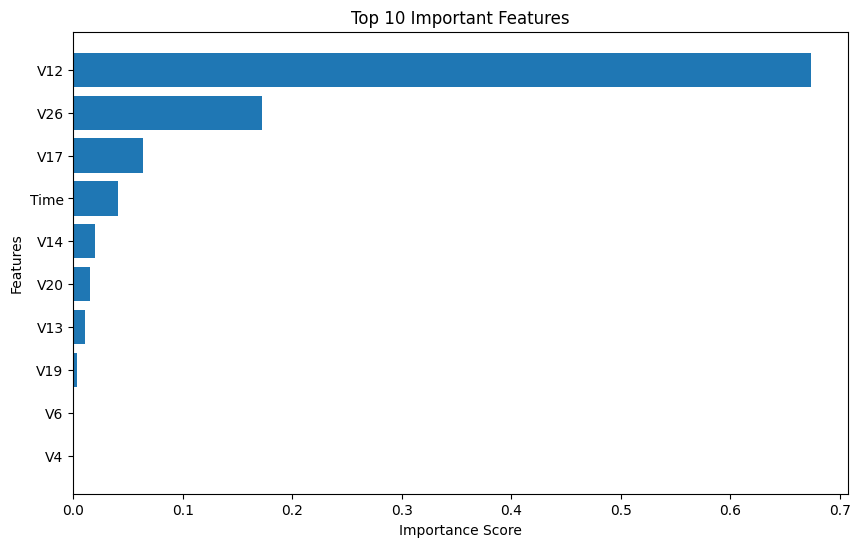

In [28]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(top_features['Feature'], top_features['Importance'])

plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Top 10 Important Features')

plt.gca().invert_yaxis()

plt.show()

📌 Step 22 — Decision Tree Visualization

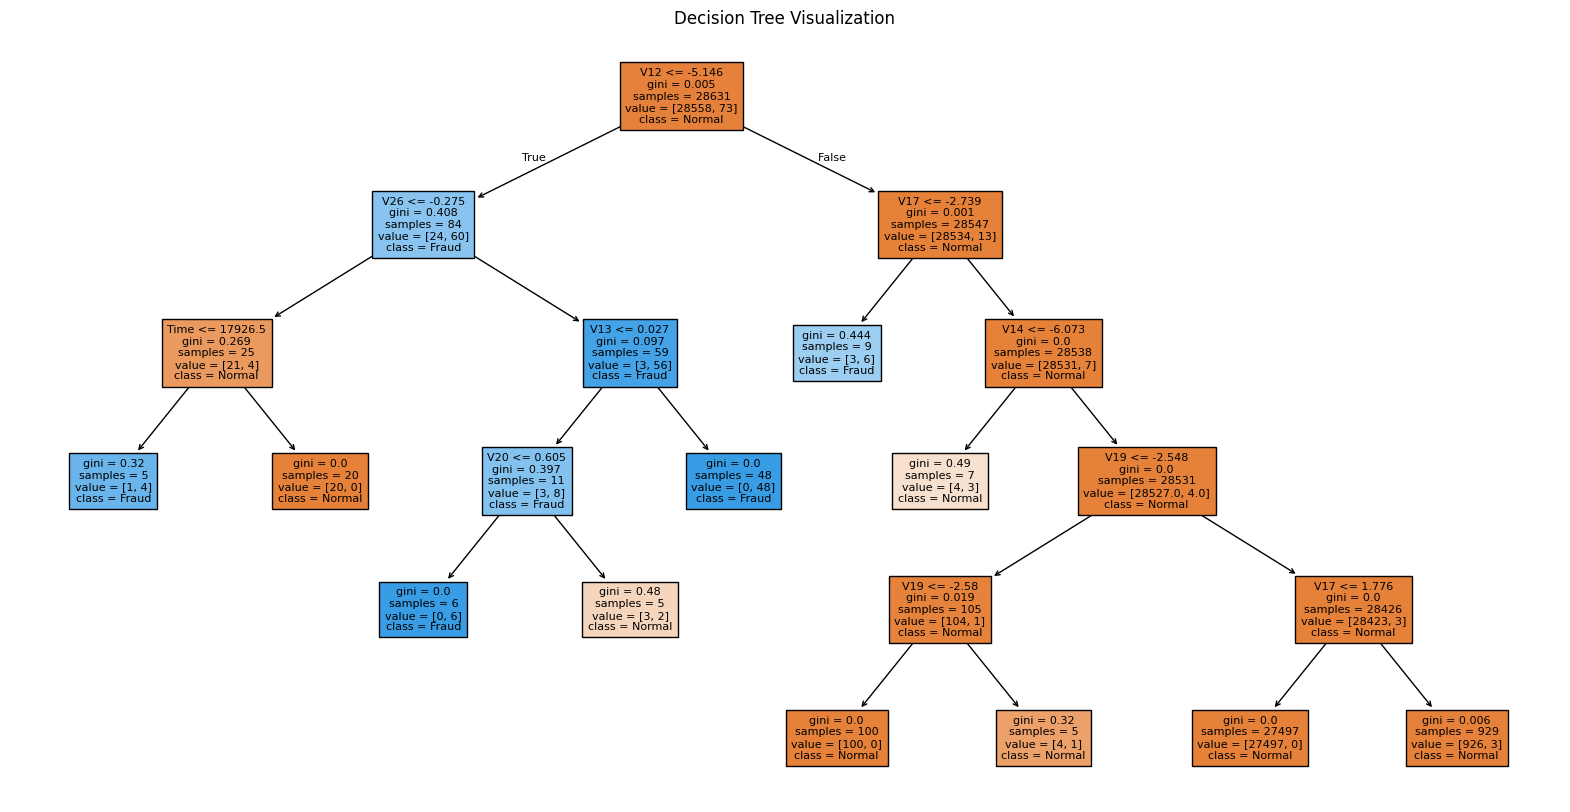

In [30]:
plt.figure(figsize=(20,10))

plot_tree(
    model,
    filled=True,
    feature_names=X.columns,
    class_names=['Normal','Fraud'],
    fontsize=8
)

plt.title('Decision Tree Visualization')

plt.show()

📌 Step 23 — Predict Single New Transaction

In [31]:
sample_data = X_test.iloc[0:1]

prediction = model.predict(sample_data)

print("Prediction :", prediction)

if prediction[0] == 0:
    print("Normal Transaction")
else:
    print("Fraud Transaction")

Prediction : [0.]
Normal Transaction


📌 Step 24 — Compare Actual vs Predicted

In [32]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print(comparison.head(20))

    Actual  Predicted
0      0.0        0.0
1      0.0        0.0
2      0.0        0.0
3      0.0        0.0
4      0.0        0.0
5      0.0        0.0
6      0.0        0.0
7      0.0        0.0
8      0.0        0.0
9      0.0        0.0
10     0.0        0.0
11     0.0        0.0
12     0.0        0.0
13     0.0        0.0
14     0.0        0.0
15     0.0        0.0
16     0.0        0.0
17     0.0        0.0
18     0.0        0.0
19     0.0        0.0


📌 Step 25 — Overfitting Check

In [33]:
# Training Accuracy
train_pred = model.predict(X_train)
train_accuracy = accuracy_score(y_train, train_pred)

# Testing Accuracy
test_accuracy = accuracy_score(y_test, y_pred)

print("Training Accuracy :", train_accuracy)
print("Testing Accuracy  :", test_accuracy)

Training Accuracy : 0.9995459467011282
Testing Accuracy  : 0.9981841039251292


📌 Understanding Overfitting

If:

Training Accuracy = 100%
Testing Accuracy  = Low

Then Model is overfitting.

📌 Step 26 — Improve Model Using Entropy

In [37]:
entropy_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    random_state=42
)

entropy_model.fit(X_train, y_train)

entropy_pred = entropy_model.predict(X_test)

entropy_accuracy = accuracy_score(y_test, entropy_pred)

print("Entropy Model Accuracy :", entropy_accuracy)

Entropy Model Accuracy : 0.9991618941192904


📌 Step 27 — Compare Gini vs Entropy

In [38]:
comparison_df = pd.DataFrame({
    'Model': ['Gini Decision Tree', 'Entropy Decision Tree'],
    'Accuracy': [test_accuracy, entropy_accuracy]
})

print(comparison_df)

                   Model  Accuracy
0     Gini Decision Tree  0.998184
1  Entropy Decision Tree  0.999162


📌 Step 28 — Accuracy Comparison Graph

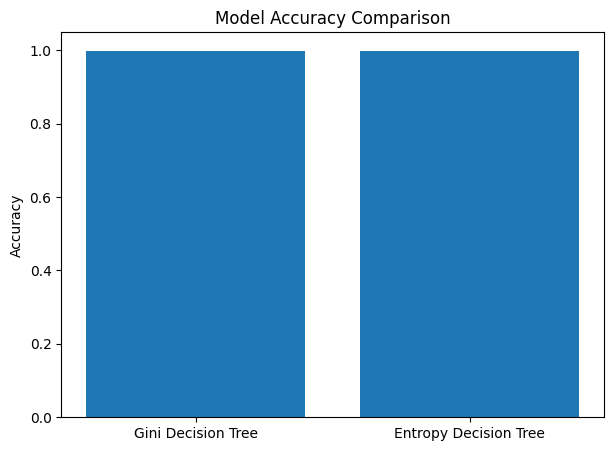

In [39]:
plt.figure(figsize=(7,5))

plt.bar(comparison_df['Model'], comparison_df['Accuracy'])

plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')

plt.show()